[![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239426-lesson-1-state-schema)

# 状态模式 

## 回顾

在module 1中，我们打下了基础！我们构建了一个能够做到以下事情的智能体： 

* `act` - 让模型调用特定的工具 
* `observe` - 将工具的数据返回给模型
* `reason` - 让模型根据工具的输出进行推理以并决定下一步做什么（例如，调用另一个工具或直接响应）
* `persist state` - 使用一个内存检查点去支持带中断的长对话
 
另外，我们还展示了怎样将在其LangGraph Studio中本地部署或使用LangGraph Cloud进行部署 

## 目标

在这个module中，我们将更深入的理解状态和记忆。

首先，让我们回顾一些定义状态模式的不同方法。

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph

## 模式

当我们定义一个 LangGraph `StateGraph`时，我们使用[状态模式](https://langchain-ai.github.io/langgraph/concepts/low_level/#state).

状态模式表示我们的图将使用的数据的结构和类型。

所有的节点都应该通过该模式进行通信

LangGraph 在怎样定义我们的状态模式方面提供了灵活性，兼容各种 Python [类型](https://docs.python.org/3/library/stdtypes.html#type-objects) 和验证方法。

## 类型字典

就像我们再Module 1中提到的，我们可以使用 python 的 `typing` 模块中的 `TypedDict` 类。

它允许我们指定键及其对应的值类型。
 
但是，请注意这些是类型提示

他们可以被静态类型检查器 (如 [mypy](https://github.com/python/mypy)) 或 IDEs 用来在代码运行前捕获潜在的与类型相关的错误。

但它们在运行时并不是强制的！

In [2]:
from typing_extensions import TypedDict

class TypedDictState(TypedDict):
    foo: str
    bar: str

对于更具体的值约束，您可以使用类似 `Literal` 的类型提示。

这里，`mood`只能是“happy”或“sad”。

In [3]:
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    mood: Literal["happy","sad"]

在 LangGraph 中，我们可以通过简单的将它传递给`StateGraph`的方式来使用我们定义的状态类(例如：这里的 `TypedDictState`) 。

并且，我们可以将每一个状态的键看做我们图中的一个“通道”。

如 Module 1中所述，我们在每个节点中覆盖指定键或“通道”的值。

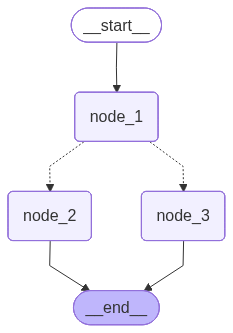

In [4]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def node_1(state):
    print("---Node 1---")
    return {"name": state['name'] + " is ... "}

def node_2(state):
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state):
    print("---Node 3---")
    return {"mood": "sad"}

def decide_mood(state) -> Literal["node_2", "node_3"]:
        
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

# Build graph
builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

因为我们的状态是一个字典，所以我们只需简单的用一个字典来调用图，去为我们状态的 `name` 键设置初始值。

In [5]:
graph.invoke({"name":"Lance"})

---Node 1---
---Node 3---


{'name': 'Lance is ... ', 'mood': 'sad'}

## 数据类

python 的 [dataclass] (https://docs.python.org/3/library/dataclasses.html) 提供了 [另外一种定义结构化数据的方式](https://www.datacamp.com/tutorial/python-data-classes).

dataclass 提供了一种简洁的语法来创建主要用来存储数据的类。

In [6]:
from dataclasses import dataclass

@dataclass
class DataclassState:
    name: str
    mood: Literal["happy","sad"]

要访问一个`dataclass`的键，我们只需要修改 `node_1` 中使用下标的方式：

* 我们使用 `state.name` 表示 `dataclass` 状态，而不是像上边的`TypedDict`一样使用`state["name"]`。

你将发现有一点奇怪：在每个节点，我们仍然返回一个字典去执行状态变更。
 
这是因为 LangGraph 分别存储了你的状态对象的每一个键。

节点返回的对象只需要拥有与状态中匹配的键（属性）即可！

在这个例子中，`dataclass` 拥有 `name` 键，所以我们可以通过从我们的节点传递一个字典来更新它，就像我们当状态是`TypedDict`时做的一样。

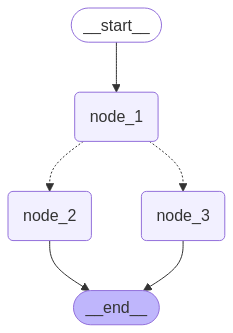

In [7]:
def node_1(state):
    print("---Node 1---")
    return {"name": state.name + " is ... "}

# Build graph
builder = StateGraph(DataclassState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

We invoke with a `dataclass` to set the initial values of each key / channel in our state!

In [8]:
graph.invoke(DataclassState(name="Lance",mood="sad"))

---Node 1---
---Node 2---


{'name': 'Lance is ... ', 'mood': 'happy'}

## Pydantic

如前所述，`TypedDict` 和 `dataclasses` 提供了类型提示，但他们在运行时并不强制类型。
 
这意味着你可能会在不抛出错误的情况下设置一个不合法的值！

例如，我们可以将 `mood` 设置为 `mad` ，即使我们的类型提示指定了 `mood: list[Literal["happy","sad"]]`.

In [9]:
dataclass_instance = DataclassState(name="Lance", mood="mad")

[Pydantic](https://docs.pydantic.dev/latest/api/base_model/) 是一个使用 Python 类型注解进行数据验证和设置管理的库。

它非常适合 [在 LangGraph 中定义状态模式](https://langchain-ai.github.io/langgraph/how-tos/state-model/) ，因为他具有验证能力。

Pydantic 可以在运行时执行验证，去检查数据是否符合指定的类型和约束。

In [ ]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel):
    name: str
    mood: str # "happy" or "sad" 

    @field_validator('mood')
    @classmethod
    def validate_mood(cls, value):
        # Ensure the mood is either "happy" or "sad"
        if value not in ["happy", "sad"]:
            raise ValueError("Each mood must be either 'happy' or 'sad'")
        return value

try:
    state = PydanticState(name="John Doe", mood="mad")
except ValidationError as e:
    print("Validation Error:", e)

Validation Error: 1 validation error for PydanticState
mood
  Value error, Each mood must be either 'happy' or 'sad' [type=value_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/value_error


我们可以无缝地在我们的图中使用 `PydanticState`。

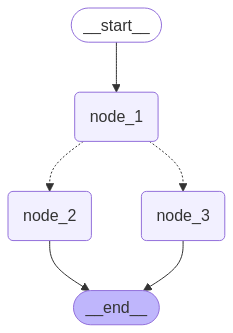

In [11]:
# Build graph
builder = StateGraph(PydanticState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke(PydanticState(name="Lance",mood="sad"))

---Node 1---
---Node 3---


{'name': 'Lance is ... ', 'mood': 'sad'}

In [16]:
try:
    graph.invoke(PydanticState(name="Lance",mood="mad"))
except Exception as e:
    print("Validation Error:", e)


Validation Error: 1 validation error for PydanticState
mood
  Value error, Each mood must be either 'happy' or 'sad' [type=value_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/value_error
